# Obtenção dos dados e preparação

In [1]:
# Importando bibliotecas e módulos
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

In [2]:
# Importando os dados do csv na url
url = 'https://www.tesourotransparente.gov.br/ckan/dataset/df56aa42-484a-4a59-8184-7676580c81e3/resource/796d2059-14e9-44e3-80c9-2d9e30b405c1/download/PrecoTaxaTesouroDireto.csv'
df = pd.read_csv(url, sep=";")

# Renomeando as colunas
df.columns = ['titulo', 'vencimento', 'data', 'tx_compra', 'tx_venda', 'pu_compra', 'pu_venda', 'pu_base']

# Transformando os tipos de dados
df['titulo'] = df['titulo'].apply(lambda x: x.replace("Tesouro ", ""))
df['vencimento'] = pd.to_datetime(df["vencimento"], format='%d/%m/%Y', errors='coerce')
df['data'] = pd.to_datetime(df["data"], format='%d/%m/%Y', errors='coerce')
df['tx_compra'] = pd.to_numeric(df['tx_compra'].apply(lambda x: x.replace(",", ".")), errors='coerce').astype('float') / 100
df['tx_venda'] = pd.to_numeric(df['tx_venda'].apply(lambda x: x.replace(",", ".")), errors='coerce').astype('float') / 100
df['pu_compra'] = pd.to_numeric(df['pu_compra'].apply(lambda x: x.replace(",", ".")), errors='coerce').astype('float')
df['pu_venda'] = pd.to_numeric(df['pu_venda'].apply(lambda x: x.replace(",", ".")), errors='coerce').astype('float')
df['pu_base'] = pd.to_numeric(df['pu_base'].apply(lambda x: x.replace(",", ".")), errors='coerce').astype('float')

# Validando as transformações
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 136505 entries, 0 to 136504
Data columns (total 8 columns):
 #   Column      Non-Null Count   Dtype         
---  ------      --------------   -----         
 0   titulo      136505 non-null  object        
 1   vencimento  136505 non-null  datetime64[ns]
 2   data        136505 non-null  datetime64[ns]
 3   tx_compra   136505 non-null  float64       
 4   tx_venda    136505 non-null  float64       
 5   pu_compra   136505 non-null  float64       
 6   pu_venda    136505 non-null  float64       
 7   pu_base     136505 non-null  float64       
dtypes: datetime64[ns](2), float64(5), object(1)
memory usage: 8.3+ MB


In [3]:
# Limitando o dataset ao Tesouro IPCA+ 2045
df = df[(df['titulo'] == 'IPCA+') & (df['vencimento'] == '2045-05-15')]
print(df['titulo'].unique(), df['vencimento'].unique(), df.shape)

['IPCA+'] ['2045-05-15T00:00:00.000000000'] (1691, 8)


In [4]:
# Excluindo as colunas de título e vencimento
df.drop(['titulo', 'vencimento'], axis=1, inplace=True)

# Visualizando as primeiras linhas do dataset
df.head()

,data,tx_compra,tx_venda,pu_compra,pu_venda,pu_base
37959,2023-07-12,0.0560,0.0572,1259.68,1228.68,1228.68
37995,2023-07-11,0.0565,0.0577,1246.53,1215.86,1215.86
38085,2023-11-14,0.0586,0.0598,1227.89,1197.95,1197.95
38155,2023-10-03,0.0598,0.0610,1187.08,1158.10,1158.10
38205,2023-08-25,0.0560,0.0572,1270.68,1239.38,1239.38


# Análise Exploratória

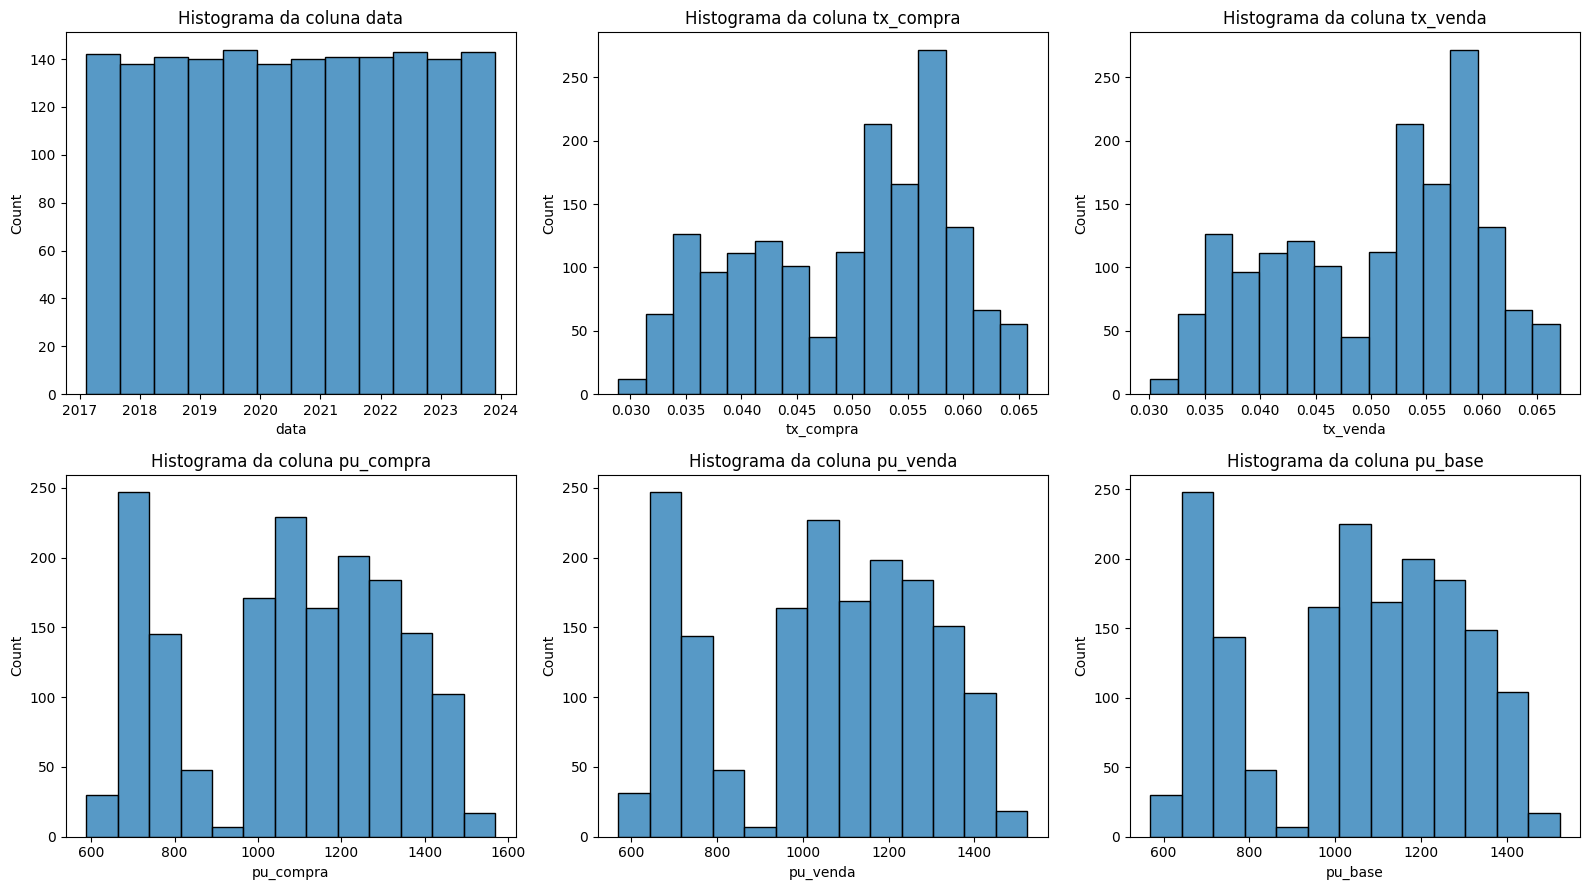

In [18]:
# Histograma para visualizar distribuição
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.ravel()

for i, coluna in enumerate(df.columns):
  ax = axes[i]
  sns.histplot(df[coluna], ax=ax)
  ax.set_title(f'Histograma da coluna {coluna}')

plt.tight_layout()
plt.show()

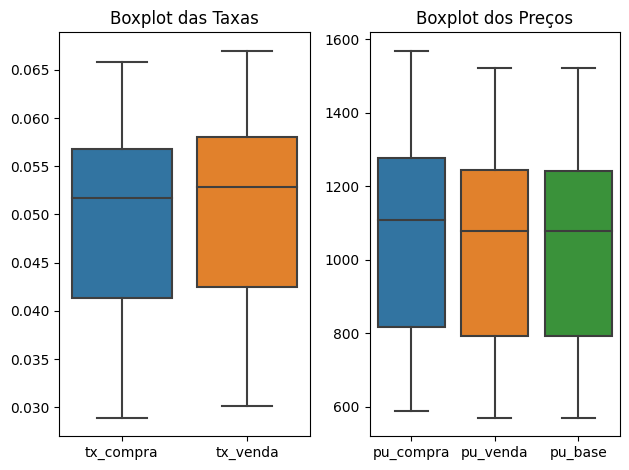

In [45]:
# Boxplot para visualizar distribuição numericamente
df_taxas = df.iloc[:,1:3]
df_precos = df.iloc[:, 3:]

fig, axes = plt.subplots(1, 2)
axes = axes.ravel()

sns.boxplot(df_taxas, ax=axes[0])
sns.boxplot(df_precos, ax=axes[1])

axes[0].set_title("Boxplot das Taxas")
axes[1].set_title("Boxplot dos Preços")

plt.tight_layout()
plt.show()

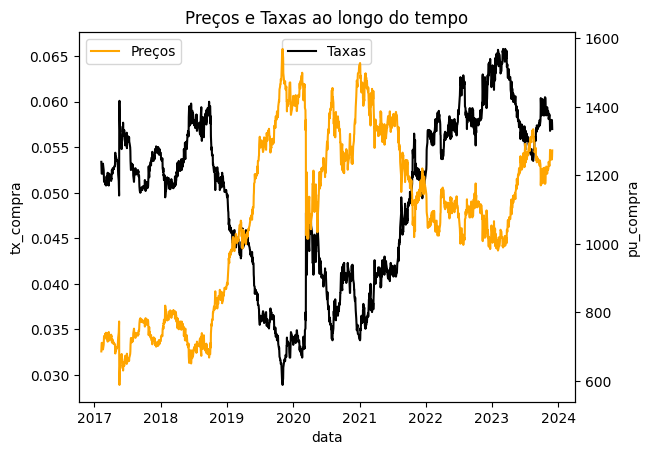

In [60]:
# Preços e Taxas com relação ao tempo
# Utilizarei taxas de compra e preços de compra pra facilitar a comparação
fig, ax1 = plt.subplots()
ax2 = ax1.twinx()

sns.lineplot(df, x='data', y='tx_compra', color='black', ax=ax1, label='Taxas')
sns.lineplot(df, x='data', y='pu_compra', color='orange', ax=ax2, label='Preços')

plt.title('Preços e Taxas ao longo do tempo')
ax1.legend(loc='upper center')
ax2.legend(loc='upper left')
plt.show()

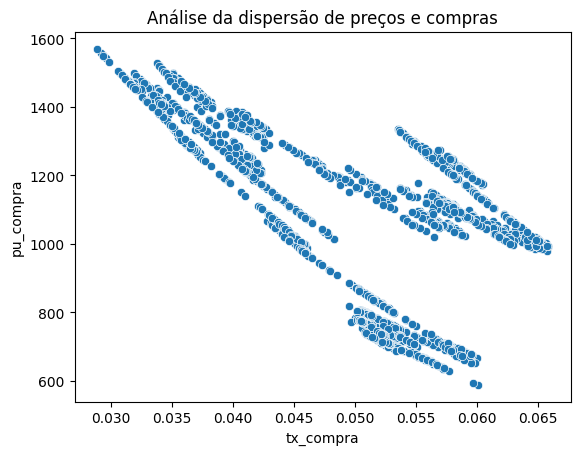

In [62]:
# Distribuição de Taxas X Preços
# Utilizarei taxas de compra e preços de compra pra facilitar a comparação

sns.scatterplot(x=df['tx_compra'], y=df['pu_compra'])
plt.title('Análise da dispersão de preços e compras')
plt.show()

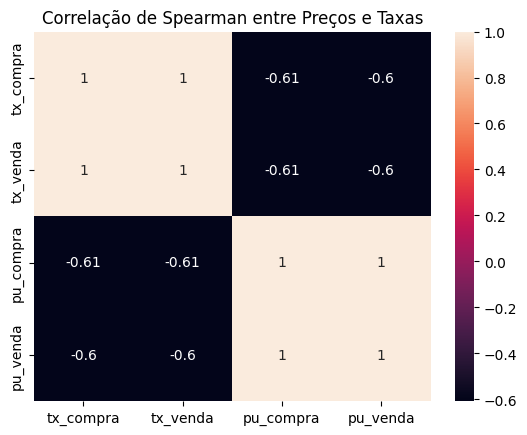

In [63]:
#Quantificação da correlação
df_corr = df.iloc[:, 1:-1].corr(method='spearman')
sns.heatmap(df_corr, annot=True)
plt.title('Correlação de Spearman entre Preços e Taxas')
plt.show()

# Regressão

Score do modelo: 0.6320982851600121


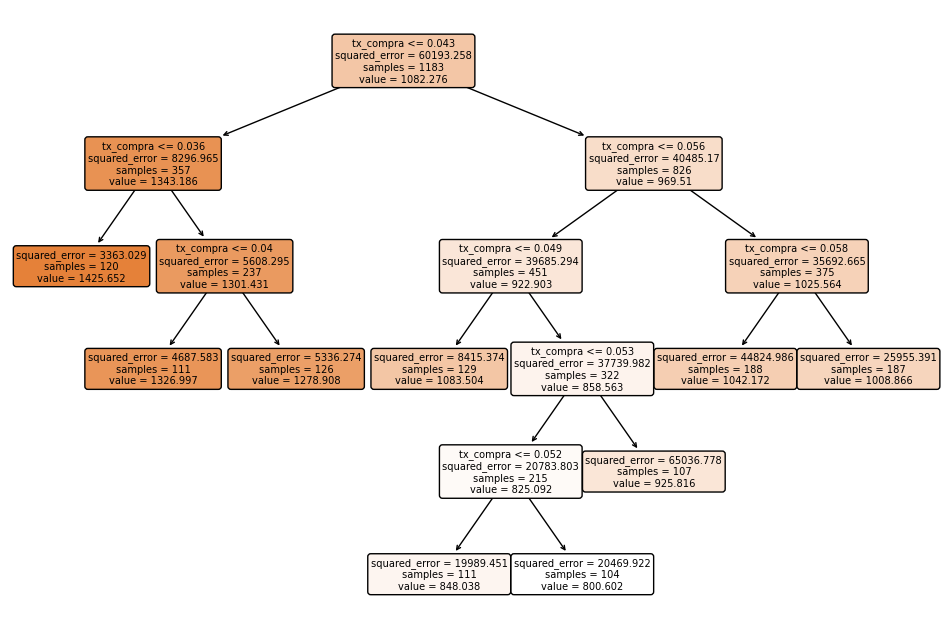

In [68]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor, plot_tree

# Separando os dados em X e y
X = df[['tx_compra']]
y = df['pu_compra']

# Dividindo os dados em conjuntos de treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Criando o modelo de árvore de regressão
tree_model = DecisionTreeRegressor(random_state=42, min_samples_leaf=100)

# Treinando o modelo
tree_model.fit(X_train, y_train)

# Avaliando o modelo (aqui você pode usar métricas como MSE, MAE, etc.)
print("Score do modelo:", tree_model.score(X_test, y_test))

# Visualizando a árvore
plt.figure(figsize=(12, 8))
plot_tree(tree_model, filled=True, feature_names=['tx_compra'], rounded=True)
plt.show()